# to test glm center estimation of sRF

In [ ]:
%load_ext autoreload
%autoreload 2

In [15]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any

from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load config
import sys
import os
from pathlib import Path


# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))



home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config
Configuration loaded successfully:
data_subfolders:
  day: 20250717
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs
  table_parameters:
    PreprocessParams:
      fs_resample: 60
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
        framerate: 5
    DNoiseTraceParams:
      dnoise_params_id: 1
      fupsample_trace: 20
      fupsample_stim: 4
      ref_time: stim
      fit_kind: gradient
      skip_duplicates: true
      pre_blur_sigma_s: 0.0
      post_blur_sigma_s: 0.0
paths:
  repo_directory: /gpfs01/euler/User/

In [ ]:
from simulations.loop_components.dj_wrappers import DJTableHolder


In [5]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )



In [6]:

# Load config and tables
dj_table_holder.load_config()
dj_table_holder.load_tables()
print(" loaded and configured successfully")
# dj_table_holder.clear_tables("all")

#dj_table_holder.setup()




[2025-08-14 17:15:18,257][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-08-14 17:15:18,316][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop
 loaded and configured successfully


In [8]:
dj_table_holder("FitGauss2DRF")().populate()

{'success_count': 99, 'error_list': []}

In [23]:
(dj_table_holder("FitGauss2DRF")() & dict(roi_id=33)).fetch1("srf_params")

{'amplitude': 0.26013551882805547,
 'x_mean': 6.9736971709146784,
 'y_mean': 10.274709248252908,
 'x_stddev': 1.1195782664669898,
 'y_stddev': 1.5785941594830704,
 'theta': -0.44956010572317856}

In [22]:
(dj_table_holder("PeakSTAPosition")() & dict(roi_id=33))

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,dnoise_params_id unique param set id,sta_params_id unique param set id,rf_peak_x_um,rf_peak_y_um
closedlooptest,2025-07-17,1,1,GCL1,RR,iter0,densenoise,control,33,1,1,1,20.0,0.0


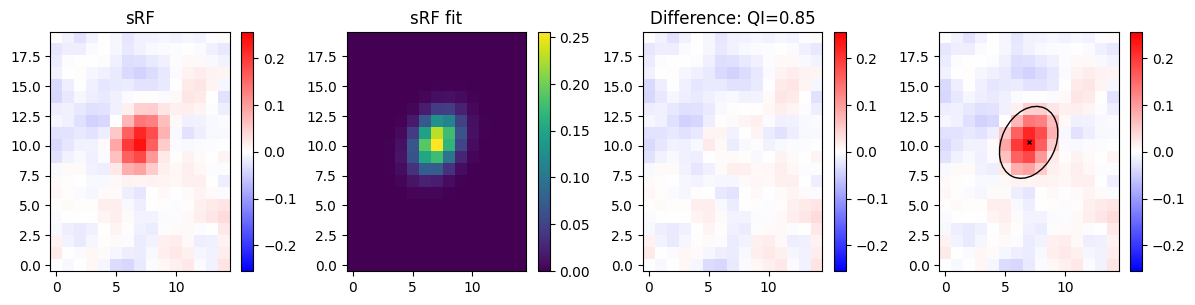

In [24]:
(dj_table_holder("FitGauss2DRF")() & dict(roi_id=33)).plot1()

In [16]:
all_parmas = (dj_table_holder("FitGauss2DRF")()).fetch("srf_params")
print(max([p["x_mean"] for p in all_parmas]))
print(np.argmax([p["y_mean"] for p in all_parmas]))

14.22277003229159
92
